<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
k-NN for Regression 
</p>

In [1]:
# Imports - core utils, data wrangling, ML, optimization, and plotting

# Standard library
import os
import pickle
import time
import warnings

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# KNN pipeline and preprocessing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer

# Model selection and evaluation
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.model_selection import learning_curve

# Bayesian optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# Suppress known compatibility/noise warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skopt")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load data & folds
</p>

In [2]:
# Paths 
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "knn_bayes_cv_results.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "knn_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]

# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Feature/target setup
feature_names = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

required_cols = [target_col, "device_id", *feature_names]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

# Train/test matrices
X_train_df = df_train[feature_names].copy()
X_test_df  = df_test[feature_names].copy()

X_train = X_train_df.to_numpy()
y_train = df_train[target_col].astype(float).to_numpy()

X_test = X_test_df.to_numpy()
y_test = df_test[target_col].astype(float).to_numpy()

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))


Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Fold sizes: {np.int64(0): np.int64(554543), np.int64(1): np.int64(277271), np.int64(2): np.int64(277271), np.int64(3): np.int64(277271), np.int64(4): np.int64(277271)}


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
kNN Model And Search Setup
</p>

In [4]:
# KNN pipeline and Bayesian search space
if not cv_splits:
    raise ValueError("No validation splits found for KNN search.")

min_train_size = min(len(tr_idx) for tr_idx, _ in cv_splits)
if min_train_size <= 0:
    raise ValueError("CV leaves no training rows for at least one fold.")

candidate_low, candidate_high = 20, 300
clamped_low = min(candidate_low, min_train_size)
clamped_high = min(candidate_high, min_train_size)
if clamped_low > clamped_high:
    clamped_low = max(1, clamped_high)


def create_knn_pipeline(n_jobs=1):
    return Pipeline([
        ("power", "passthrough"),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(leaf_size=30, n_jobs=n_jobs)),
    ])


search_spaces_knn = {
    "power": Categorical([
        "passthrough",
        PowerTransformer(method="yeo-johnson", standardize=False),
    ]),
    "scaler": Categorical([StandardScaler(), RobustScaler()]),
    "knn__n_neighbors": Integer(clamped_low, clamped_high),
    "knn__weights": Categorical(["uniform", "distance"]),
    "knn__metric": Categorical(["manhattan", "euclidean"]),
}

if clamped_high < candidate_high:
    print(
        f"Clamped n_neighbors upper bound to {clamped_high} "
        "based on the smallest CV training fold."
    )


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 Bayesian optimization
</p>

In [5]:
# Setup for multi-metric scoring
scoring = {"neg_root_mean_squared_error": "neg_root_mean_squared_error", "r2": "r2"}

# Bayesian optimization, scoring on both RMSE and R2
bayes_cv_knn = BayesSearchCV(
    estimator=create_knn_pipeline(n_jobs=1),
    search_spaces=search_spaces_knn,
    n_iter=60,
    scoring=scoring,
    refit="neg_root_mean_squared_error",
    n_jobs=8,
    cv=cv_splits,
    random_state=42,
    verbose=1,
    n_points=2,
    return_train_score=False,
    error_score="raise",
    optimizer_kwargs={
        "base_estimator": "GP",
        "n_initial_points": 15,
        "acq_func": "gp_hedge",
    },
)

print(
    f"Starting Bayesian optimization with {bayes_cv_knn.n_iter} iterations "
    f"and {len(cv_splits)}-fold cross-validation per candidate...\n"
)

t0 = time.time()
bayes_cv_knn.fit(X_train_df, y_train)
t1 = time.time()
print(f"\nBayesian optimization complete in {(t1 - t0) / 60:.2f} minutes.")

bayes_results_knn = pd.DataFrame(bayes_cv_knn.cv_results_)
print(f"\nTried {bayes_results_knn.shape[0]} configurations.")

bayes_results_knn.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nSaved BayesSearchCV cv_results_ to: {CV_RESULTS_PATH}")


Starting Bayesian optimization with 60 iterations and 5-fold cross-validation per candidate...

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitt

In [6]:
# Load saved CV-search results and derive the best KNN parameters robustly
legacy_cv_result_paths = [
    os.path.join("KNN", "Results", "knn_bayes_cv_results.csv"),
    os.path.join("Results", "knn_bayes_cv_results.csv"),
]

if os.path.exists(CV_RESULTS_PATH):
    bayes_results_knn = pd.read_csv(CV_RESULTS_PATH)
else:
    bayes_results_knn = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            bayes_results_knn = pd.read_csv(legacy_path)
            bayes_results_knn.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy CV results to: {CV_RESULTS_PATH}")
            break

    if bayes_results_knn is None:
        raise FileNotFoundError(
            f"No CV results found. Run the BayesSearchCV cell or provide {CV_RESULTS_PATH}."
        )

if bayes_results_knn.empty:
    raise ValueError("Loaded CV results are empty.")

expected_param_cols = {f"param_{name}" for name in search_spaces_knn.keys()}
actual_param_cols = {c for c in bayes_results_knn.columns if c.startswith("param_")}
if actual_param_cols != expected_param_cols:
    raise ValueError(
        "Loaded KNN CV results do not match the current search space. "
        "Re-run the BayesSearchCV cell before deriving best_knn_params. "
        f"Expected {sorted(expected_param_cols)}, got {sorted(actual_param_cols)}."
    )

required_cv_cols = [
    "mean_test_neg_root_mean_squared_error",
    "std_test_neg_root_mean_squared_error",
    "mean_test_r2",
    "std_test_r2",
    "param_knn__n_neighbors",
]
missing_cv_cols = [c for c in required_cv_cols if c not in bayes_results_knn.columns]
if missing_cv_cols:
    raise KeyError(f"Missing expected CV result columns: {missing_cv_cols}")

# Best overall configuration by validation RMSE
best_idx = bayes_results_knn["mean_test_neg_root_mean_squared_error"].idxmax()
best_row = bayes_results_knn.loc[best_idx]


def _parse_knn_param(name, value):
    if pd.isna(value):
        return None

    text = str(value)

    if name == "knn__n_neighbors":
        return int(round(float(value)))
    if name in {"knn__weights", "knn__metric"}:
        return text
    if name == "power":
        if "PowerTransformer" in text:
            return PowerTransformer(method="yeo-johnson", standardize=False)
        return "passthrough"
    if name == "scaler":
        if "RobustScaler" in text:
            return RobustScaler()
        return StandardScaler()
    return value


if "bayes_cv_knn" in locals() and hasattr(bayes_cv_knn, "best_params_"):
    best_knn_params = bayes_cv_knn.best_params_
else:
    best_knn_params = {}
    for col in [c for c in bayes_results_knn.columns if c.startswith("param_")]:
        name = col.replace("param_", "")
        parsed_value = _parse_knn_param(name, best_row[col])
        if parsed_value is not None:
            best_knn_params[name] = parsed_value

best_cv_rmse = -float(best_row["mean_test_neg_root_mean_squared_error"])
best_cv_r2 = float(best_row["mean_test_r2"])

print("Best KNN Parameters Found:", best_knn_params)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")
print(f"Best CV R2:   {best_cv_r2:.4f}")

# Best-per-K summary for plotting
bayes_results_knn["K"] = pd.to_numeric(
    bayes_results_knn["param_knn__n_neighbors"], errors="coerce"
).astype("Int64")

param_cols = [c.replace("param_", "") for c in bayes_results_knn.columns if c.startswith("param_")]
rows = []
for K in sorted(bayes_results_knn["K"].dropna().unique()):
    df_k = bayes_results_knn[bayes_results_knn["K"] == K]
    idx = df_k["mean_test_neg_root_mean_squared_error"].idxmax()
    row = df_k.loc[idx]

    summary_row = {
        "K": int(K),
        "best_cv_rmse": -row["mean_test_neg_root_mean_squared_error"],
        "std_cv_rmse": row["std_test_neg_root_mean_squared_error"],
        "best_cv_r2": row["mean_test_r2"],
        "std_cv_r2": row["std_test_r2"],
    }

    for param in param_cols:
        summary_row[param] = row[f"param_{param}"]

    rows.append(summary_row)

cv_knn_df = pd.DataFrame(rows).sort_values("K").reset_index(drop=True)

tbl = cv_knn_df.copy()
num_cols = tbl.select_dtypes(include="number").columns
tbl[num_cols] = tbl[num_cols].round(4)

tbl_t = tbl.set_index("K").T
tbl_t.index.name = "metric/param"
tbl_t.columns = [f"K={int(c)}" for c in tbl_t.columns]
display(tbl_t)

Best KNN Parameters Found: OrderedDict([('knn__metric', 'manhattan'), ('knn__n_neighbors', 300), ('knn__weights', 'distance'), ('power', PowerTransformer(standardize=False)), ('scaler', StandardScaler())])
Best CV RMSE: 6.2266
Best CV R2:   0.8886


,K=20,K=59,K=64,K=65,K=68,K=87,K=110,K=118,K=139,K=140,...,K=267,K=274,K=276,K=277,K=278,K=281,K=283,K=289,K=299,K=300
metric/param,,,,,,,,,,,,,,,,,,,,,
best_cv_rmse,6.5773,6.4658,6.4635,6.3618,6.7127,6.3321,6.4408,6.3437,6.5227,6.4951,...,6.5335,6.231,6.2346,6.231,6.3233,6.2274,6.441,6.2316,6.322,6.2266
std_cv_rmse,0.4243,0.4371,0.4376,0.4181,0.3887,0.4181,0.3913,0.4637,0.411,0.3934,...,0.3624,0.4368,0.4684,0.437,0.3856,0.434,0.4085,0.4386,0.3856,0.4359
best_cv_r2,0.876,0.8801,0.8801,0.8839,0.8709,0.8849,0.881,0.8844,0.878,0.879,...,0.8777,0.8884,0.8884,0.8884,0.8853,0.8886,0.8811,0.8884,0.8853,0.8886
std_cv_r2,0.0201,0.02,0.02,0.0196,0.0189,0.0195,0.0191,0.0206,0.0193,0.0191,...,0.0181,0.0203,0.0202,0.0204,0.0188,0.0202,0.0184,0.0204,0.0188,0.0203
knn__metric,manhattan,manhattan,manhattan,manhattan,euclidean,manhattan,euclidean,manhattan,euclidean,euclidean,...,euclidean,manhattan,manhattan,manhattan,euclidean,manhattan,euclidean,manhattan,euclidean,manhattan
knn__n_neighbors,20,59,64,65,68,87,110,118,139,140,...,267,274,276,277,278,281,283,289,299,300
knn__weights,distance,uniform,distance,uniform,distance,distance,distance,distance,distance,uniform,...,uniform,uniform,uniform,uniform,uniform,distance,uniform,uniform,distance,distance
power,PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),passthrough,passthrough,passthrough,...,PowerTransformer(standardize=False),PowerTransformer(standardize=False),passthrough,PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False),passthrough,PowerTransformer(standardize=False),PowerTransformer(standardize=False),PowerTransformer(standardize=False)
scaler,StandardScaler(),RobustScaler(),RobustScaler(),StandardScaler(),RobustScaler(),StandardScaler(),StandardScaler(),RobustScaler(),RobustScaler(),StandardScaler(),...,RobustScaler(),StandardScaler(),RobustScaler(),StandardScaler(),StandardScaler(),StandardScaler(),RobustScaler(),StandardScaler(),StandardScaler(),StandardScaler()


In [7]:
# Build the selected KNN pipeline from the best CV parameters
best_knn_model = create_knn_pipeline(n_jobs=-1)
best_knn_model.set_params(**best_knn_params)
print("Selected KNN parameters:", best_knn_params)

Selected KNN parameters: OrderedDict([('knn__metric', 'manhattan'), ('knn__n_neighbors', 300), ('knn__weights', 'distance'), ('power', PowerTransformer(standardize=False)), ('scaler', StandardScaler())])


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: Best CV RMSE & its STD vs K
</p>

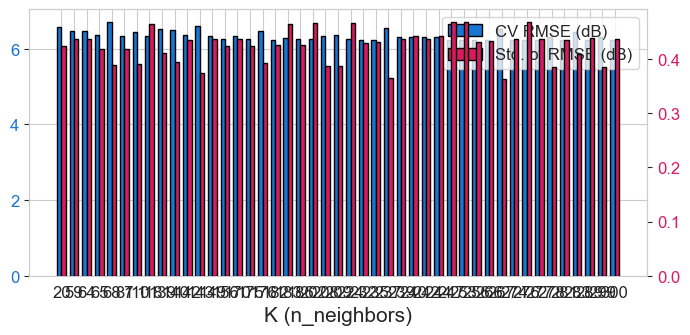

In [8]:
# Display KNN CV RMSE and RMSE variability across all searched K values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df = cv_knn_df.sort_values("K").reset_index(drop=True)
x = np.arange(len(cv_knn_df["K"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_knn_df["best_cv_rmse"],
    bar_width,
    color="#1976d2",
    label="RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df["K"].astype(int), fontsize=tick_fontsize, rotation=0)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_knn_df["std_cv_rmse"],
    bar_width,
    color="#d81b60",
    label="Std. of RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE (dB)"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

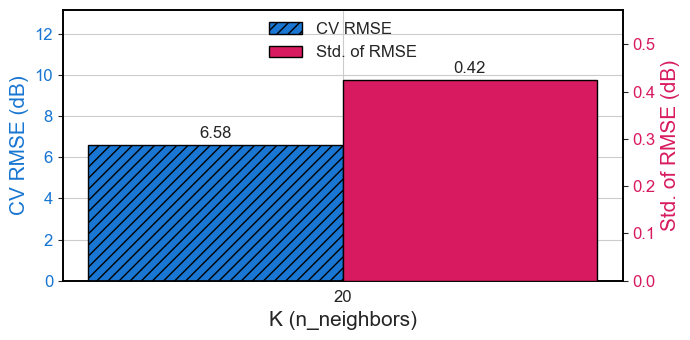

Saved figure: Figures\KNN_bestRMSE_STD_perK.png


In [9]:
# Plot and save the focused KNN CV RMSE figure based on k

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df_plot = cv_knn_df.copy()
cv_knn_df_plot["K"] = pd.to_numeric(cv_knn_df_plot["K"], errors="coerce")
cv_knn_df_plot = cv_knn_df_plot[cv_knn_df_plot["K"].isin([5, 10, 15, 20, 25, 30])].copy()
cv_knn_df_plot = cv_knn_df_plot.sort_values("K").reset_index(drop=True)

if cv_knn_df_plot.empty:
    raise ValueError("No KNN CV rows available for K = 5, 10, 15, 20, 25, 30.")

x = np.arange(len(cv_knn_df_plot["K"]))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(x - bar_width / 2, cv_knn_df_plot["best_cv_rmse"].astype(float), bar_width, color="#1976d2", edgecolor="black", linewidth=1, zorder=3)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color="#1976d2")
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df_plot["K"].astype(int), fontsize=tick_fontsize, rotation=0)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width / 2, cv_knn_df_plot["std_cv_rmse"].astype(float), bar_width, color="#d81b60", edgecolor="black", linewidth=1, zorder=3)
ax2.set_ylabel("Std. of RMSE (dB)", fontsize=axis_labelsize, color="#d81b60")
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(cv_knn_df_plot["best_cv_rmse"].max()) * 2.0)
ax2.set_ylim(0, float(cv_knn_df_plot["std_cv_rmse"].max()) * 1.35)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", hatch="///", label="CV RMSE"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE"),
]
leg = ax1.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.50, 0.98), borderaxespad=0.0, fontsize=legend_fontsize, frameon=False)

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "KNN_bestRMSE_STD_perK.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: Best CV R² & its STD vs K
</p>

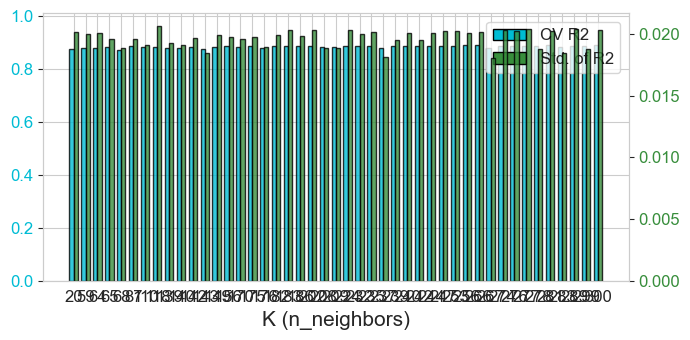

In [10]:
# Display KNN CV R2 and R2 variability across searched K values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df = cv_knn_df.sort_values("K").reset_index(drop=True)
x = np.arange(len(cv_knn_df["K"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_knn_df["best_cv_r2"],
    bar_width,
    color="#00bcd4",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="R2",
)
ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df["K"].astype(int), fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#00bcd4", labelsize=tick_fontsize)
ax1.tick_params(axis="x", labelsize=tick_fontsize)
ax1.set_ylim(0, 1.01)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_knn_df["std_cv_r2"],
    bar_width,
    color="#388e3c",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="Std. of R2",
)
ax2.tick_params(axis="y", labelcolor="#388e3c", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#00bcd4", edgecolor="black", label="CV R2"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#388e3c", edgecolor="black", label="Std. of R2"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Train best KNN on full train set, evaluate on test, and save model
</p>

In [11]:
# Train final model, evaluate on held-out test, and save model/residual artifacts

best_knn_model = create_knn_pipeline(n_jobs=-1)
best_knn_model.set_params(**best_knn_params)
best_knn_model.fit(X_train_df, y_train)

print("Best KNN Parameters Used:", best_knn_params)
print("\nFinal KNN model trained on the full training split.")

# Train/test predictions
y_train_pred = best_knn_model.predict(X_train_df)
y_test_pred = best_knn_model.predict(X_test_df)

# OOF predictions using the selected best parameters
# This avoids reporting kNN's optimistic self-neighbor training error as the main train diagnostic.
y_pred_oof = np.full(len(y_train), np.nan, dtype=float)
if not cv_splits:
    raise ValueError("No validation splits found for OOF residual generation.")

for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):

    fold_model = create_knn_pipeline(n_jobs=1)
    fold_model.set_params(**best_knn_params)
    fold_model.fit(X_train_df.iloc[tr_idx], y_train[tr_idx])
    y_pred_oof[val_idx] = fold_model.predict(X_train_df.iloc[val_idx])

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = y_train[mask] - PL_pred_oof

if mask.sum() != len(y_train):
    print(f"OOF residuals generated for {mask.sum()} of {len(y_train)} training rows.")

# Metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
oof_mse = mean_squared_error(y_train[mask], PL_pred_oof)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
oof_rmse = np.sqrt(oof_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
oof_r2 = r2_score(y_train[mask], PL_pred_oof)

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_median_ae = median_absolute_error(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    "Metric": [
        "Train MSE (apparent)", "Train RMSE (apparent)", "Train R2 (apparent)",
        "OOF MSE", "OOF RMSE", "OOF R2",
        "Test MSE", "Test RMSE", "Test R2",
        "Test MAPE (%)", "Test Median AE",
    ],
    "Value": [
        train_mse, train_rmse, train_r2,
        oof_mse, oof_rmse, oof_r2,
        test_mse, test_rmse, test_r2,
        test_mape * 100, test_median_ae,
    ],
})

print("\nModel Evaluation Metrics:")
display(metrics_df)

# Save final model
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_knn_model, f)
print(f"\nTrained KNN model saved to: {MODEL_PATH}")

# TEST residuals
PL_pred_test = y_test_pred
resid_test = y_test - PL_pred_test

knn_test_df = pd.DataFrame({
    "model":       "KNN",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     y_test,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_KNN_test.csv")
knn_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved KNN test residuals: {test_residual_path}")

# OOF residuals
knn_oof_df = pd.DataFrame({
    "model":       "KNN",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     y_train[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_KNN_oof.csv")
knn_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved KNN OOF residuals: {oof_residual_path}")


Best KNN Parameters Used: OrderedDict([('knn__metric', 'manhattan'), ('knn__n_neighbors', 300), ('knn__weights', 'distance'), ('power', PowerTransformer(standardize=False)), ('scaler', StandardScaler())])

Final KNN model trained on the full training split.

Model Evaluation Metrics:


,Metric,Value
0,Train MSE (apparent),0.000000
1,Train RMSE (apparent),0.000000
2,Train R2 (apparent),1.000000
3,OOF MSE,38.092714
4,OOF RMSE,6.171930
5,OOF R2,0.892403
6,Test MSE,24.800522
7,Test RMSE,4.980012
8,Test R2,0.930042
9,Test MAPE (%),4.288104



Trained KNN model saved to: Models\knn_final_model.pkl
[TEST] Saved KNN test residuals: Residuals\residuals_KNN_test.csv
[OOF] Saved KNN OOF residuals: Residuals\residuals_KNN_oof.csv


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Learning curve
</p>

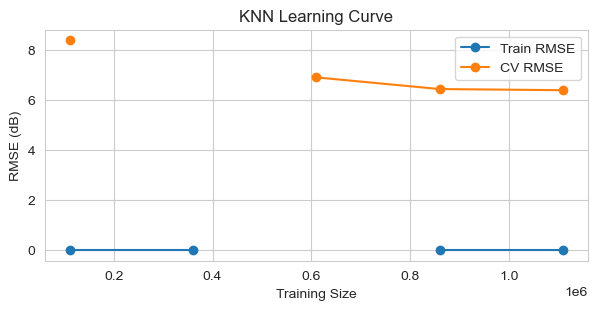

In [12]:
# KNN learning curve with the predefined time-aware folds

figsize = (7, 3)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_knn_model,
    X=X_train_df,
    y=y_train,
    cv=cv_splits,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="neg_root_mean_squared_error",
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -test_scores.mean(axis=1)

plt.figure(figsize=figsize)
plt.plot(train_sizes, train_rmse_curve, "o-", label="Train RMSE")
plt.plot(train_sizes, val_rmse_curve, "o-", label="CV RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE (dB)")
plt.title("KNN Learning Curve")
plt.legend()
plt.show()


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Residuals 
</p>

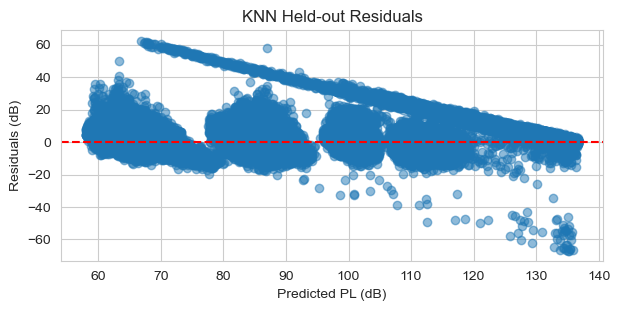

In [13]:
# Held-out residual plot

plt.figure(figsize=(7, 3))
plt.scatter(y_test_pred, resid_test, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted PL (dB)")
plt.ylabel("Residuals (dB)")
plt.title("KNN Held-out Residuals")
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Physics consistency: PL vs log10(distance)
</p>

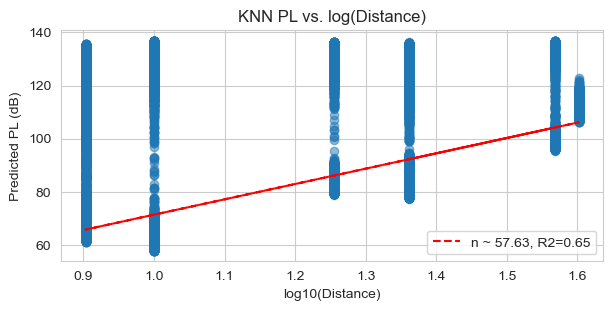

In [14]:
# Physics consistency: predicted PL vs. log10(distance)

dist = df_test["distance"].to_numpy()
log_dist = np.log10(dist + 1e-6)
slope, intercept, r_value, _, _ = linregress(log_dist, y_test_pred)

plt.figure(figsize=(7, 3))
plt.scatter(log_dist, y_test_pred, alpha=0.5)
plt.plot(log_dist, intercept + slope * log_dist, "r--", label=f"n ~ {slope:.2f}, R2={r_value**2:.2f}")
plt.xlabel("log10(Distance)")
plt.ylabel("Predicted PL (dB)")
plt.title("KNN PL vs. log(Distance)")
plt.legend()
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Predicted vs Real
</p>

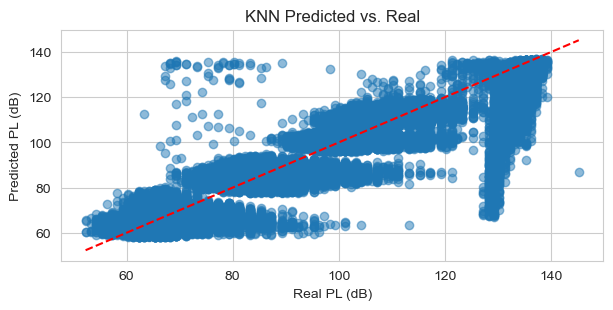

In [15]:
# Predicted vs. real PL on the held-out test split

plt.figure(figsize=(7, 3))
plt.scatter(y_test, y_test_pred, alpha=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Real PL (dB)")
plt.ylabel("Predicted PL (dB)")
plt.title("KNN Predicted vs. Real")
plt.show()